In [ ]:
import requests
import pandas as pd
from datetime import datetime
import time

In [408]:
# Scraping Main Menus
def scrape_lunch_menus(df_schools, year="2026", month="03"):
    
    date_map = {
        'week_1': "01",
        'week_2': "08",
        'week_3': "15",
        'week_4': "22",
        'week_5': "29"
    }
    current_date = list(date_map.keys())[0]
    current_date_call = list(date_map.values())[0]
    all_rows = []
    
    for _, row in df_schools.iterrows():
        
        school_name = row.iloc[0]   # first column
        raw_url = row.iloc[2]      # third column
        base_url = raw_url.rstrip("/")
        base_url = "/".join(base_url.split("/")[:-3])
        print(f"Scraping school: {school_name}")
        
        for current_date, current_date_call in date_map.items():
            
            url = f"{base_url}/{year}/{month}/{current_date_call}/"
            
            try:
                r = requests.get(url)
                data = r.json()
            except Exception as e:
                print(f"Failed: {school_name} - {current_date}")
                print("Error:", e)
                continue
            
            for day in data.get("days", []):
                menu_items = day.get("menu_items", [])
                
                if not menu_items:
                    continue
                
                date = day.get("date")
                
                for item in menu_items:
                    menu_id = item.get("id")
                    category = item.get("category")
                    food = item.get("food", {})
                    
                    if not food:
                        continue
                    
                    nutrition = food.get("rounded_nutrition_info", {}) or {}
                    serving_size_info = food.get("serving_size_info", {}) or {}
                    
                    all_rows.append({
                        "school_name": school_name,
                        "menu_id": menu_id,
                        "date": date,
                        "food_id": food.get("id"),
                        "food_name": food.get("name"),
                        "category": category,
                        "ingredients": food.get("ingredients"),
                        "cal": nutrition.get("calories"),
                        "g_fat": nutrition.get("g_fat"),
                        "g_sat_fat": nutrition.get("g_saturated_fat"),
                        "g_trans_fat": nutrition.get("g_trans_fat"),
                        "mg_cholesterol": nutrition.get("mg_cholesterol"),
                        "g_carbs": nutrition.get("g_carbs"),
                        "g_added_sugar": nutrition.get("g_added_sugar"),
                        "g_sugar": nutrition.get("g_sugar"),
                        "mg_potassium": nutrition.get("mg_potassium"),
                        "mg_sodium": nutrition.get("mg_sodium"),
                        "g_fiber": nutrition.get("g_fiber"),
                        "g_protein": nutrition.get("g_protein"),
                        "mg_iron": nutrition.get("mg_iron"),
                        "mg_calcium": nutrition.get("mg_calcium"),
                        "mg_vitamin_c": nutrition.get("mg_vitamin_c"),
                        "iu_vitamin_a": nutrition.get("iu_vitamin_a"),
                        "mg_vitamin_d": nutrition.get("mg_vitamin_d"),
                        "serving_size_amount": serving_size_info.get("serving_size_amount"),
                        "serving_size_unit": serving_size_info.get("serving_size_unit"),
                    })
    
    df_all = pd.DataFrame(all_rows).drop_duplicates().reset_index(drop=True)
    
    return df_all

### Loading the CSV file

In [410]:
school_nutrislice_df = pd.read_csv("/Users/oliviangai/Desktop/Data_400_final_project/school_API_links.csv")

### Running the main menu function

In [413]:
main_menus_df = scrape_lunch_menus(school_nutrislice_df, year="2026", month="03")

Scraping school: Littlestown Area High - Littlestown Area School District - PA
Scraping school: Upper Adams Intermediate School - Upper Adams School District - PA
Scraping school: Upper Adams MIddle School - Upper Adams School District - PA
Scraping school: Cornell High School - Cornell School District - PA
Scraping school: Elizabeth Forward High School - Elizabeth Forward School District - PA
Scraping school: Elizabeth Forward Middle School - Elizabeth Forward School District - PA
Scraping school: Montour High School - Montour School District - PA
Scraping school: Montoursville Area High - Montoursville Area School District - PA
Scraping school: Northgate Middle/High School - Northgate School District - PA
Scraping school: Pine-Richland High School - Pine-Richland School District - PA
Scraping school: Pine-Richland Middle School - Pine-Richland School District - PA
Scraping school: West Mifflin Area High - West Mifflin Area School District - PA
Scraping school: West Mifflin Area Middl

In [415]:
main_menus_df.head()

,school_name,menu_id,date,food_id,food_name,category,ingredients,cal,g_fat,g_sat_fat,...,mg_sodium,g_fiber,g_protein,mg_iron,mg_calcium,mg_vitamin_c,iu_vitamin_a,mg_vitamin_d,serving_size_amount,serving_size_unit
0,Littlestown Area High - Littlestown Area Schoo...,404274997,2026-03-02,1203626,Chicken Tenders,entree,,260.0,15.0,2.5,...,390.0,3.0,15.0,2.0,40.0,NaN,NaN,0.0,3,piece
1,Littlestown Area High - Littlestown Area Schoo...,404274999,2026-03-02,1086885,Baked Beans,vegetable,,150.0,0.0,0.0,...,550.0,5.0,7.0,1.9,50.0,NaN,NaN,0.0,0.5,cups
2,Littlestown Area High - Littlestown Area Schoo...,404275000,2026-03-02,1653406,Whole Grain Dinner Roll,grain,,180.0,3.0,0.5,...,340.0,5.0,6.0,1.6,70.0,0.0,0.0,0.0,2,each
3,Littlestown Area High - Littlestown Area Schoo...,404275002,2026-03-02,1164571,Classic Cheese Pizza,entree,,340.0,15.0,7.0,...,710.0,3.0,18.0,2.0,410.0,NaN,NaN,NaN,1,slice
4,Littlestown Area High - Littlestown Area Schoo...,404275005,2026-03-02,1983332,Classic American Cheeseburger,entree,,300.0,11.0,4.5,...,600.0,3.0,24.0,3.5,180.0,NaN,NaN,NaN,1,sandwich


### Menu Subsections

In [379]:
import requests
import pandas as pd

def scrape_api_messages(df_schools):
    records = []

    for _, row in df_schools.iterrows():
        school_name = row.iloc[0]
        api_url = row.iloc[3]

        print(f"Scraping: {school_name}")

        try:
            response = requests.get(api_url)
            data = response.json()

            # Skip first dictionary + filter for food_list
            food_lists = [item for item in data if item.get("type") == "food_list"]

            for food_list in food_lists:
                menu_id = food_list.get("id")
                content = food_list.get("content")
                for item in content.get("menu_items", []):
                    category = item.get("category")
                    food = item.get("food", {})
                    if not food:
                        continue

                    nutrition = food.get("rounded_nutrition_info", {}) or {}
                    serving_size_info = food.get("serving_size_info", {}) or {}

                    records.append({
                        "school_name": school_name,
                        "menu_id": menu_id,
                        "date": "daily",
                        "food_id": food.get("id"),
                        "food_name": food.get("name"),
                        "category": category,
                        "ingredients": food.get("ingredients"),
                        "cal": nutrition.get("calories"),
                        "g_fat": nutrition.get("g_fat"),
                        "g_sat_fat": nutrition.get("g_saturated_fat"),
                        "g_trans_fat": nutrition.get("g_trans_fat"),
                        "mg_cholesterol": nutrition.get("mg_cholesterol"),
                        "g_carbs": nutrition.get("g_carbs"),
                        "g_added_sugar": nutrition.get("g_added_sugar"),
                        "g_sugar": nutrition.get("g_sugar"),
                        "mg_potassium": nutrition.get("mg_potassium"),
                        "mg_sodium": nutrition.get("mg_sodium"),
                        "g_fiber": nutrition.get("g_fiber"),
                        "g_protein": nutrition.get("g_protein"),
                        "mg_iron": nutrition.get("mg_iron"),
                        "mg_calcium": nutrition.get("mg_calcium"),
                        "mg_vitamin_c": nutrition.get("mg_vitamin_c"),
                        "iu_vitamin_a": nutrition.get("iu_vitamin_a"),
                        "mg_vitamin_d": nutrition.get("mg_vitamin_d"),
                        "serving_size_amount": serving_size_info.get("serving_size_amount"),
                        "serving_size_unit": serving_size_info.get("serving_size_unit"),
                    })

        except Exception as e:
            print(f"Failed: {school_name}")
            print(f"Error: {e}")
    df_all = pd.DataFrame(records).drop_duplicates().reset_index(drop=True)
    return df_all

In [339]:
api_message_menus = scrape_api_messages(school_nutrislice_df)

Scraping: Littlestown Area High - Littlestown Area School District - PA
Scraping: Upper Adams Intermediate School - Upper Adams School District - PA
Scraping: Upper Adams MIddle School - Upper Adams School District - PA
Scraping: Cornell High School - Cornell School District - PA
Scraping: Elizabeth Forward High School - Elizabeth Forward School District - PA
Scraping: Elizabeth Forward Middle School - Elizabeth Forward School District - PA
Scraping: Montour High School - Montour School District - PA
Scraping: Montoursville Area High - Montoursville Area School District - PA
Scraping: Northgate Middle/High School - Northgate School District - PA
Scraping: Pine-Richland High School - Pine-Richland School District - PA
Scraping: Pine-Richland Middle School - Pine-Richland School District - PA
Scraping: West Mifflin Area High - West Mifflin Area School District - PA
Scraping: West Mifflin Area Middle - West Mifflin Area School District - PA
Scraping: Beaver Area High - Beaver Area School 

In [369]:
main_menus_df.shape


(49313, 26)

## Combining the DataFrames

In [397]:
combined_df = pd.concat([main_menus_df, api_message_menus], ignore_index=True)

### Amount of empty category values

In [485]:
print((combined_df['category'].isna() | (combined_df['category'] == '')).sum())

18573


In [504]:
print(combined_df['school_name'].nunique())

98


In [475]:
combined_df.head

<bound method NDFrame.head of                                              school_name    menu_id  \
0      Littlestown Area High - Littlestown Area Schoo...  404274997   
1      Littlestown Area High - Littlestown Area Schoo...  404274999   
2      Littlestown Area High - Littlestown Area Schoo...  404275000   
3      Littlestown Area High - Littlestown Area Schoo...  404275002   
4      Littlestown Area High - Littlestown Area Schoo...  404275005   
...                                                  ...        ...   
51078  Yough Intermediate Middle School - Yough Schoo...      28340   
51079  Yough Intermediate Middle School - Yough Schoo...      37239   
51080  Yough Intermediate Middle School - Yough Schoo...      37239   
51081  Yough Intermediate Middle School - Yough Schoo...      37239   
51082  Yough Intermediate Middle School - Yough Schoo...      37239   

             date  food_id                            food_name   category  \
0      2026-03-02  1203626             

In [9]:
import pandas as pd

# Read the first sheet of the file
menu_data_all = pd.read_excel('/Users/oliviangai/Desktop/Data_400_final_project/important datasets/School_Menus_with_repeats.xlsx')


In [12]:
import pandas as pd

# Count missing or empty categories per school
missing_categories = menu_data_all[menu_data_all['category'].isna() | (menu_data_all['category'] == '')]\
    .groupby('school_name')['category']\
    .count()\
    .reset_index()

missing_categories.columns = ['school_name', 'missing_category_count']

# Total items per school
total_items = menu_data_all.groupby('school_name')['category']\
    .count()\
    .reset_index()

total_items.columns = ['school_name', 'total_items']

# Merge and calculate percentage
result = missing_categories.merge(total_items, on='school_name')
result['pct_missing'] = (result['missing_category_count'] / result['total_items'] * 100).round(1)

print(result.sort_values('pct_missing', ascending=False))

                                          school_name  missing_category_count  \
0   Bangor Area High School - Bangor Area School D...                       0   
22  Northern Cambria High - North Cambria School D...                       0   
30                  Susquenita High - Susquenita - PA                       0   
29  Pine-Richland High School - Pine-Richland Scho...                       0   
28  Penncrest High School - Rose Tree Media School...                       0   
27  Penn Cambria High - Penn Cambria School Distri...                       0   
26  Palmyra Area Middle School - Palmyra Area Scho...                       0   
25  Palmyra Area High School - Palmyra Area School...                       0   
24  Old Forge Jr/Sr High - Old Forge School Distri...                       0   
23  Northgate Middle/High School - Northgate Schoo...                       0   
19  Millersburg Area High School/ Middle School - ...                       0   
1   Bangor Area Middle Schoo

## Loading CSV

In [5]:
import pandas as pd

# Read the Excel file into a DataFrame
file_path = '/Users/oliviangai/Desktop/Data_400_final_project/school_menu_categories.xlsx' 
school_menu_unique = pd.read_excel(file_path)

# Display the first 5 rows of the data to verify
print(school_menu_unique.head())


   Unnamed: 0                                        school_name    menu_id  \
0       41187  Bangor Area High School - Bangor Area School D...  170689742   
1       41266  Bangor Area Middle School - Bangor Area School...  170689742   
2       50163  Millersburg Area High School/ Middle School - ...       2204   
3        5985  Beaver Area High - Beaver Area School District...  153630060   
4        7320  Beaver Area Middle - Beaver Area School Distri...  153630060   

                  date  food_id                     food_name   category  \
0  2026-03-11 00:00:00   788130  (Cheese) Hamburger on WG Bun     entree   
1  2026-03-11 00:00:00   788130  (Cheese) Hamburger on WG Bun     entree   
2                daily   261300    06 Tomato & Cucumber Salad  vegetable   
3  2026-03-02 00:00:00   288160             1% Chocolate Milk       milk   
4  2026-03-02 00:00:00   288160             1% Chocolate Milk       milk   

              ingredients    cal  g_fat  ...  mg_sodium  g_fiber  g_

In [68]:
school_menu_unique.loc[
    school_menu_unique["school_name"].isna(), "school_name"
] = "Dallastown Area High School - Dallastown Area School District - PA"

In [7]:
school_menu_unique["category"].isna().value_counts()

category
False    9666
True       50
Name: count, dtype: int64

## split school name into name and district

In [1]:
# split only on dashes WITH spaces (avoids breaking hyphenated names)
split_cols = school_menu_unique['school_name'].str.split(r'\s+-\s+', n=1, expand=True)

school_menu_unique['school'] = split_cols[0]
school_menu_unique['school_district'] = split_cols[1]

# ensure missing districts are NaN
school_menu_unique['school_district'] = school_menu_unique['school_district'].where(
    school_menu_unique['school_district'].notna(), pd.NA
)

NameError: name 'school_menu_unique' is not defined

In [88]:
school_menu_unique['school_name'].nunique()

99

## Removes duplicates

In [440]:
no_dupes = combined_df.drop_duplicates(subset=["school_name", "food_name"])

In [470]:
no_dupes.shape

(9716, 26)

In [3]:
common_entrees = no_dupes[no_dupes["category"]=="entree"]

NameError: name 'no_dupes' is not defined

## EDA

In [444]:
df_category_pivot = (
    no_dupes
    .groupby(["school_name", "category"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

In [450]:
df_category_pivot.head(100)

category,school_name,,beverage,condiment,entree,fruit,grain,meat,milk,other,side,snack,vegetable
0,Bishop Guilfoyle Catholic High School - PA,0,3,1,18,10,0,0,0,0,0,0,20
1,Bangor Area High School - Bangor Area School D...,47,0,0,1,0,0,0,0,0,2,0,0
2,Bangor Area Middle School - Bangor Area School...,47,0,0,1,0,0,0,0,0,2,0,0
3,Beaver Area High - Beaver Area School District...,126,0,0,0,0,0,0,0,0,0,0,0
4,Beaver Area Middle - Beaver Area School Distri...,126,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,Windber Area High School - Windber Area School...,0,4,3,29,3,1,0,0,0,0,0,4
94,Wissahickon High - Wissahickon School District...,0,3,0,73,12,0,0,0,0,0,0,14
95,Wissahickon Middle - Wissahickon School Distri...,0,3,0,73,12,0,0,0,0,0,0,14
96,Yough High School - Yough School District - PA,0,5,0,48,14,0,0,0,0,0,0,19


/var/folders/f2/w_z2_t3x5495kc9_2dxgrb5w0000gn/T/ipykernel_77391/2277895667.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=categories, patch_artist=True)


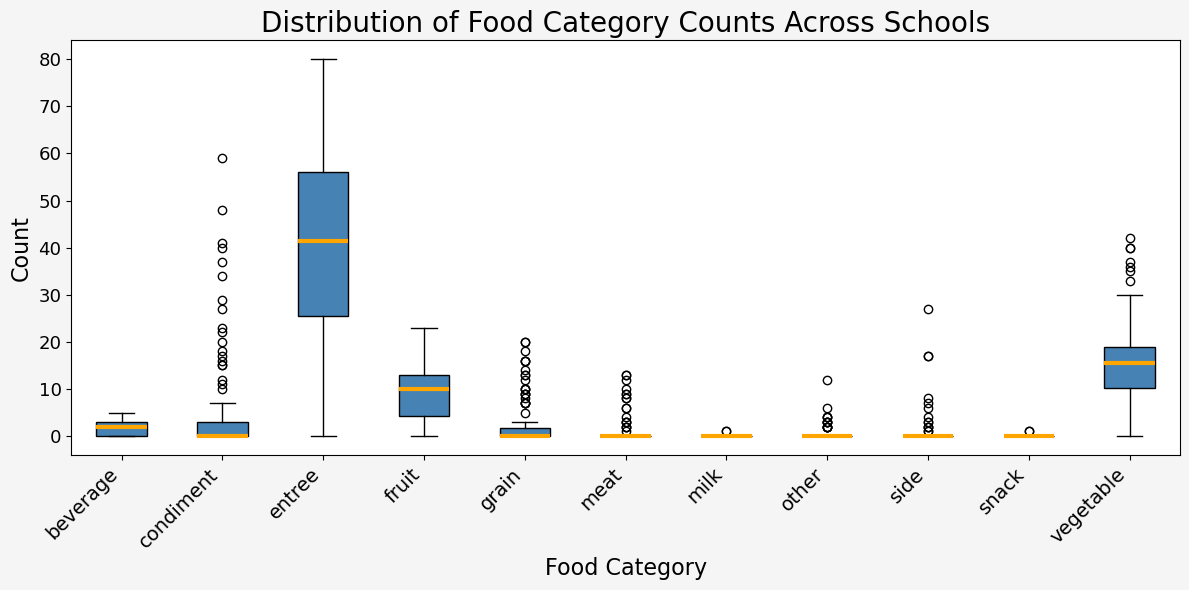

In [526]:
fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(data, labels=categories, patch_artist=True)

for patch in bp['boxes']:
    patch.set_facecolor('steelblue')

for median in bp['medians']:
    median.set_linewidth(3)
    median.set_color('orange')

#ax.set_facecolor('#f5f5f5')        # ← add this
fig.patch.set_facecolor('#f5f5f5') # ← add this

ax.set_xlabel("Food Category", fontsize=16)
ax.set_ylabel("Count", fontsize=16)
ax.set_title("Distribution of Food Category Counts Across Schools", fontsize=20)
plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()

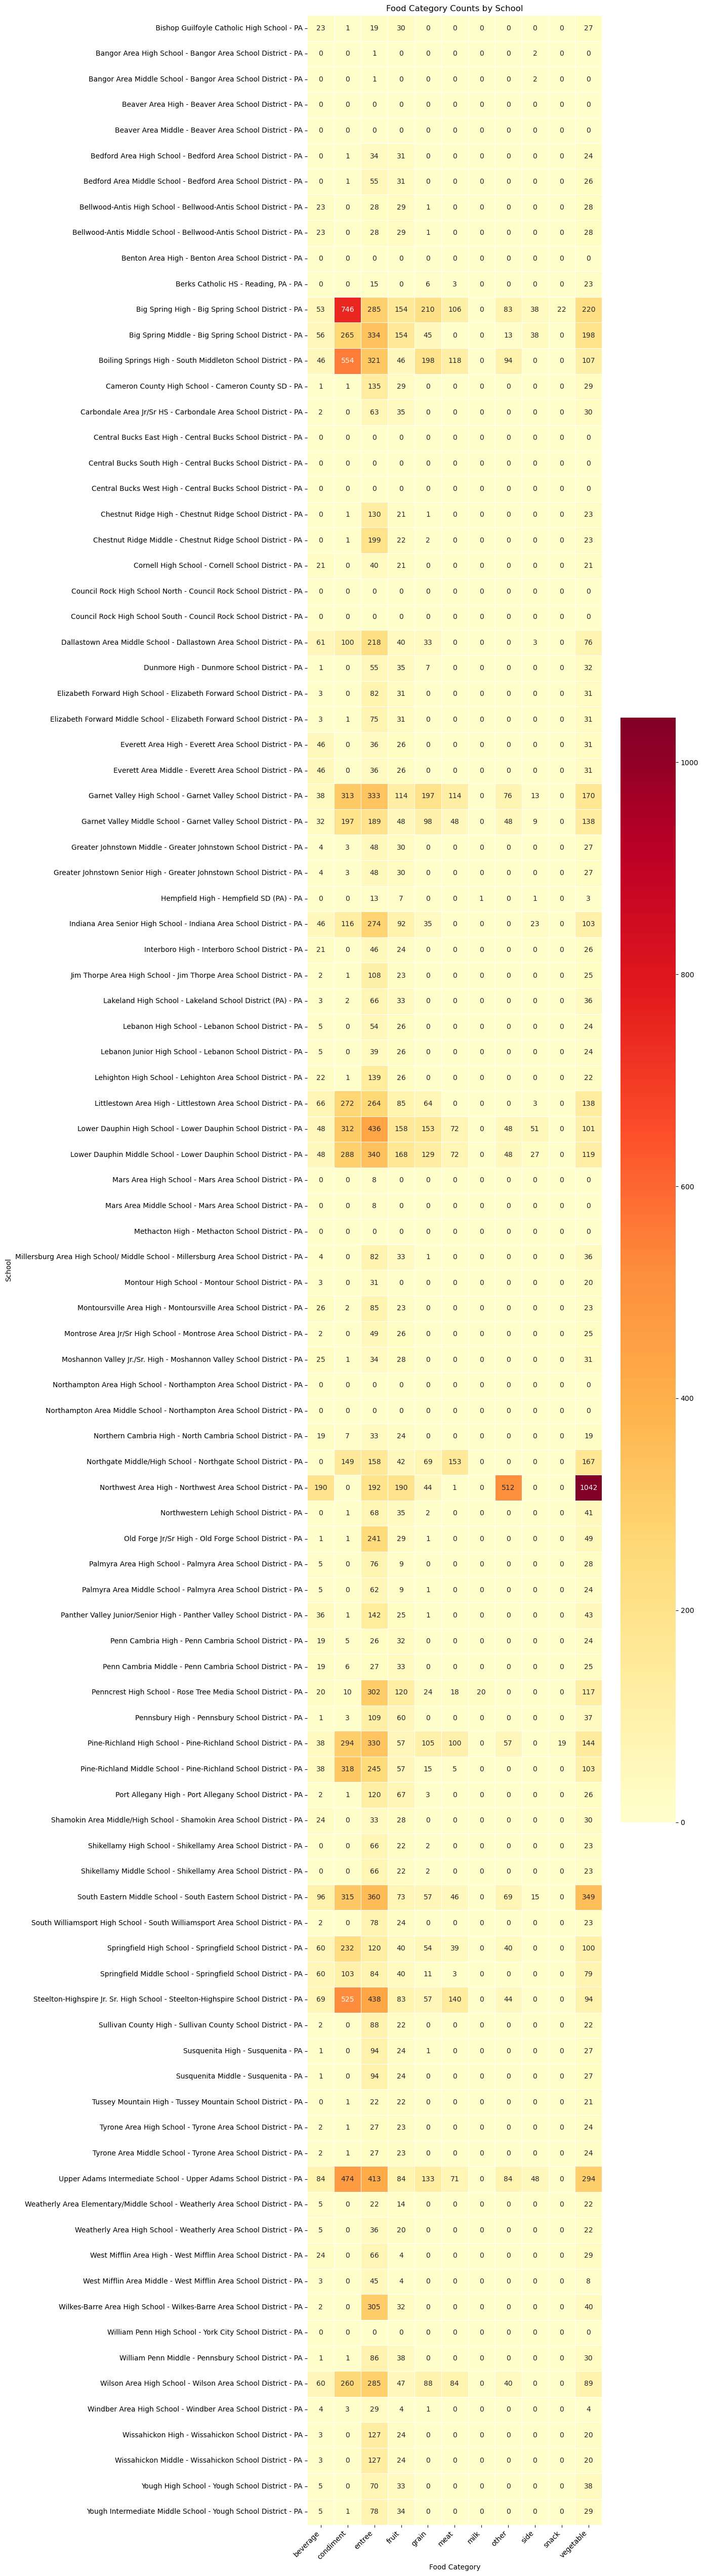

In [438]:
import matplotlib.pyplot as plt
import seaborn as sns

keep = ["beverage", "condiment", "entree", "fruit", "grain", "meat", "milk", "other", "side", "snack", "vegetable"]
categories = [col for col in df_category_pivot.columns if col.lower() in keep]

heatmap_data = df_category_pivot.set_index("school_name")[categories]

fig, ax = plt.subplots(figsize=(14, len(heatmap_data) * 0.5 + 2))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax
)
ax.set_title("Food Category Counts by School")
ax.set_xlabel("Food Category")
ax.set_ylabel("School")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [114]:
#!pip3 install wordcloud matplotlib

In [110]:
#import sys
#!{sys.executable} -m pip install wordcloud matplotlib

In [122]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [118]:
# Filter for category == "fruit" and drop any missing food names
fruit_text = " ".join(school_menu_unique.loc[school_menu_unique["category"] == "fruit", "food_name"].dropna())

In [126]:
# Filter for category == "fruit" and drop any missing food names
veggie_text = " ".join(school_menu_unique.loc[school_menu_unique["category"] == "vegetable", "food_name"].dropna())

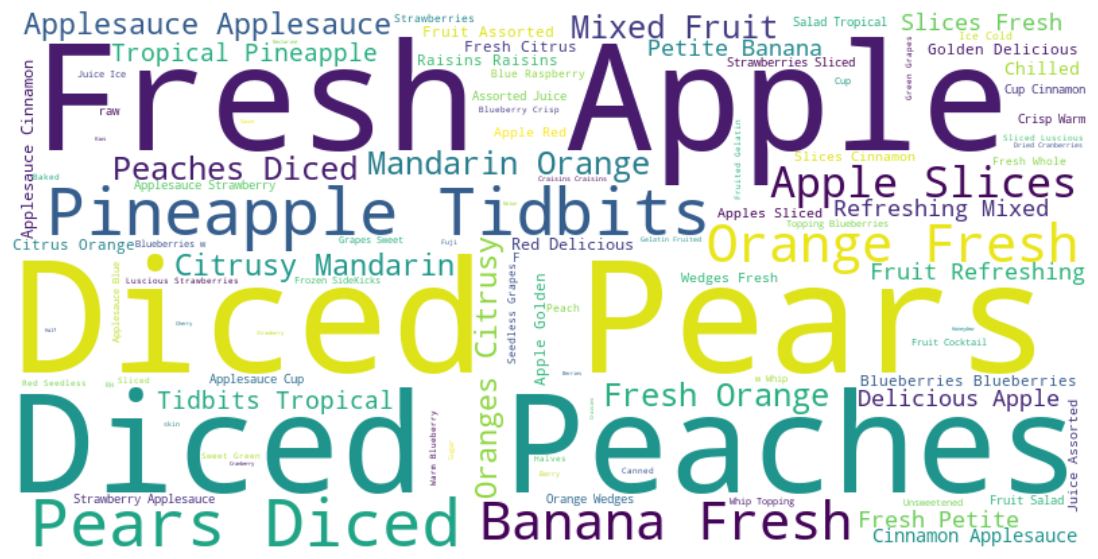

In [124]:
wc = WordCloud(width=800, height=400, background_color="white").generate(fruit_text)

plt.figure(figsize=(15,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

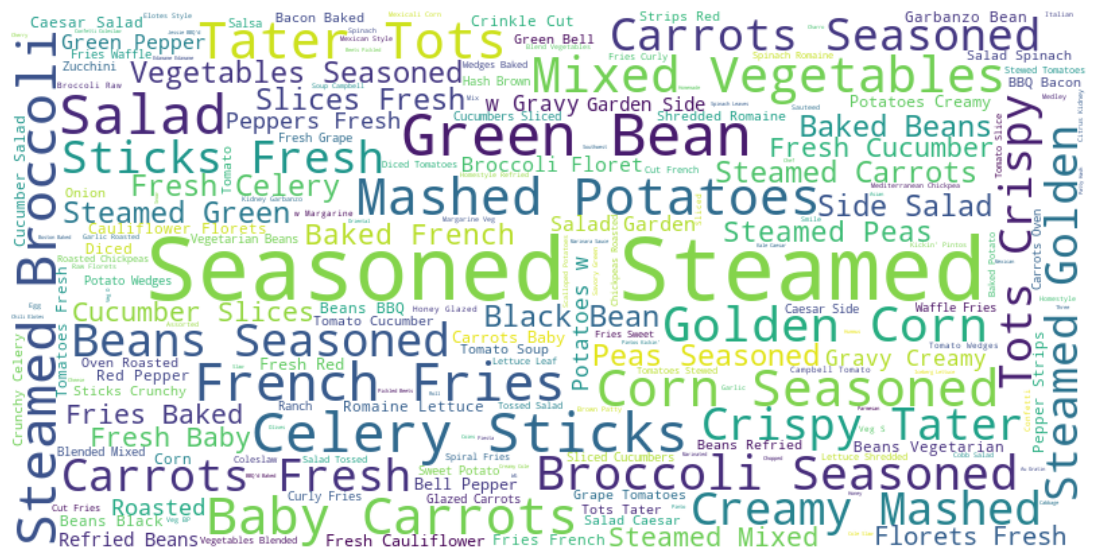

In [128]:
wc = WordCloud(width=800, height=400, background_color="white").generate(veggie_text)

plt.figure(figsize=(15,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [130]:
import pandas as pd
from collections import defaultdict
import re

# ====================== CONFIG ======================
input_file = '/Users/oliviangai/Desktop/Data_400_final_project/School_Menus.csv'      # Change if your file has a different name
output_file = 'School_Menus_FILLED.csv'

# ===================================================

# Load the data
print("Loading CSV file...")
df = pd.read_csv(input_file)

# Make sure category column exists
if 'category' not in df.columns:
    raise ValueError("Column 'category' not found in the CSV!")

# 1. Get all existing categories (exact ones only)
existing_categories = df['category'].dropna().unique().tolist()
print(f"Found {len(existing_categories)} existing categories: {existing_categories}")

# 2. Create a mapping from food_name → most common category
food_to_category = defaultdict(list)

for _, row in df.iterrows():
    if pd.notna(row['category']) and pd.notna(row['food_name']):
        food_to_category[row['food_name'].strip().lower()].append(row['category'])

# Take the most frequent category for each food
food_mapping = {}
for food, cats in food_to_category.items():
    if cats:
        food_mapping[food] = max(set(cats), key=cats.count)  # most common

print(f"Created mapping for {len(food_mapping)} unique food names.")

# 3. Function to intelligently assign category based on name
def assign_category(food_name: str) -> str:
    if pd.isna(food_name):
        return None
    
    name = str(food_name).strip().lower()
    
    # Exact match first (best)
    if name in food_mapping:
        return food_mapping[name]
    
    # Keyword-based fallback (using patterns from your data)
    if any(word in name for word in ['pizza', 'sandwich', 'wrap', 'sub', 'hoagie', 'burger', 'cheeseburger', 
                                   'tenders', 'wings', 'calzone', 'stromboli', 'uncrustable', 'parfait', 
                                   'salad with', 'chicken', 'meatball', 'taco', 'enchilada', 'bowl']):
        return 'entree'
    
    elif any(word in name for word in ['roll', 'bread', 'rice', 'croutons', 'biscuit', 'noodles', 'pasta']):
        return 'grain'
    
    elif any(word in name for word in ['fruit', 'apple', 'banana', 'orange', 'grapes', 'pineapple', 
                                     'peach', 'pear', 'mandarin', 'applesauce', 'strawberry']):
        return 'fruit'
    
    elif any(word in name for word in ['milk', 'beverage']):
        return 'beverage'
    
    elif any(word in name for word in ['dressing', 'sauce', 'ketchup', 'mustard', 'mayonnaise', 'ranch', 
                                     'caesar', 'italian dressing', 'french dressing', 'buffalo ranch']):
        return 'condiment'
    
    # Default to vegetable for most sides
    return 'vegetable'

# 4. Fill missing categories
missing_before = df['category'].isna().sum()
print(f"\nMissing categories before filling: {missing_before}")

# First try exact food name match
df['category'] = df['category'].fillna(df['food_name'].str.strip().str.lower().map(food_mapping))

# Then use intelligent function for remaining blanks
still_missing = df['category'].isna()
if still_missing.any():
    df.loc[still_missing, 'category'] = df.loc[still_missing, 'food_name'].apply(assign_category)

missing_after = df['category'].isna().sum()
print(f"Missing categories after filling: {missing_after}")

# 5. Save the result
df.to_csv(output_file, index=False)
print(f"\n✅ Done! Filled file saved as: {output_file}")
print(f"   - Rows processed: {len(df)}")
print(f"   - Categories filled: {missing_before - missing_after}")

# Optional: Show a sample of what was filled
filled_sample = df[df['food_name'].notna() & df['category'].notna()].sample(10) if len(df) > 10 else df
print("\nSample of filled data:")
print(filled_sample[['food_name', 'category']])

Loading CSV file...


/var/folders/f2/w_z2_t3x5495kc9_2dxgrb5w0000gn/T/ipykernel_94874/133782113.py:13: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)


Found 11 existing categories: ['entree', 'vegetable', 'grain', 'condiment', 'fruit', 'beverage', 'side', 'meat', 'other', 'snack', 'milk']
Created mapping for 1828 unique food names.

Missing categories before filling: 18573
Missing categories after filling: 0

✅ Done! Filled file saved as: School_Menus_FILLED.csv
   - Rows processed: 51083
   - Categories filled: 18573

Sample of filled data:
                                  food_name   category
16163                                Salami       meat
4001                                  Salsa  condiment
9519                  Seasoned Steamed Peas  vegetable
47080                Chicken Patty on a Bun     entree
49715                 Fresh Cucumber Slices  vegetable
6067                   Spinach & Feta Pizza     entree
32412                Chicken Patty Sandwich     entree
25528                          Fresh Banana      fruit
48618  WG PB & Strawberry Jelly Uncrustable     entree
6370                         Fresh Broccoli  vegetabl